# HR Analysis

# 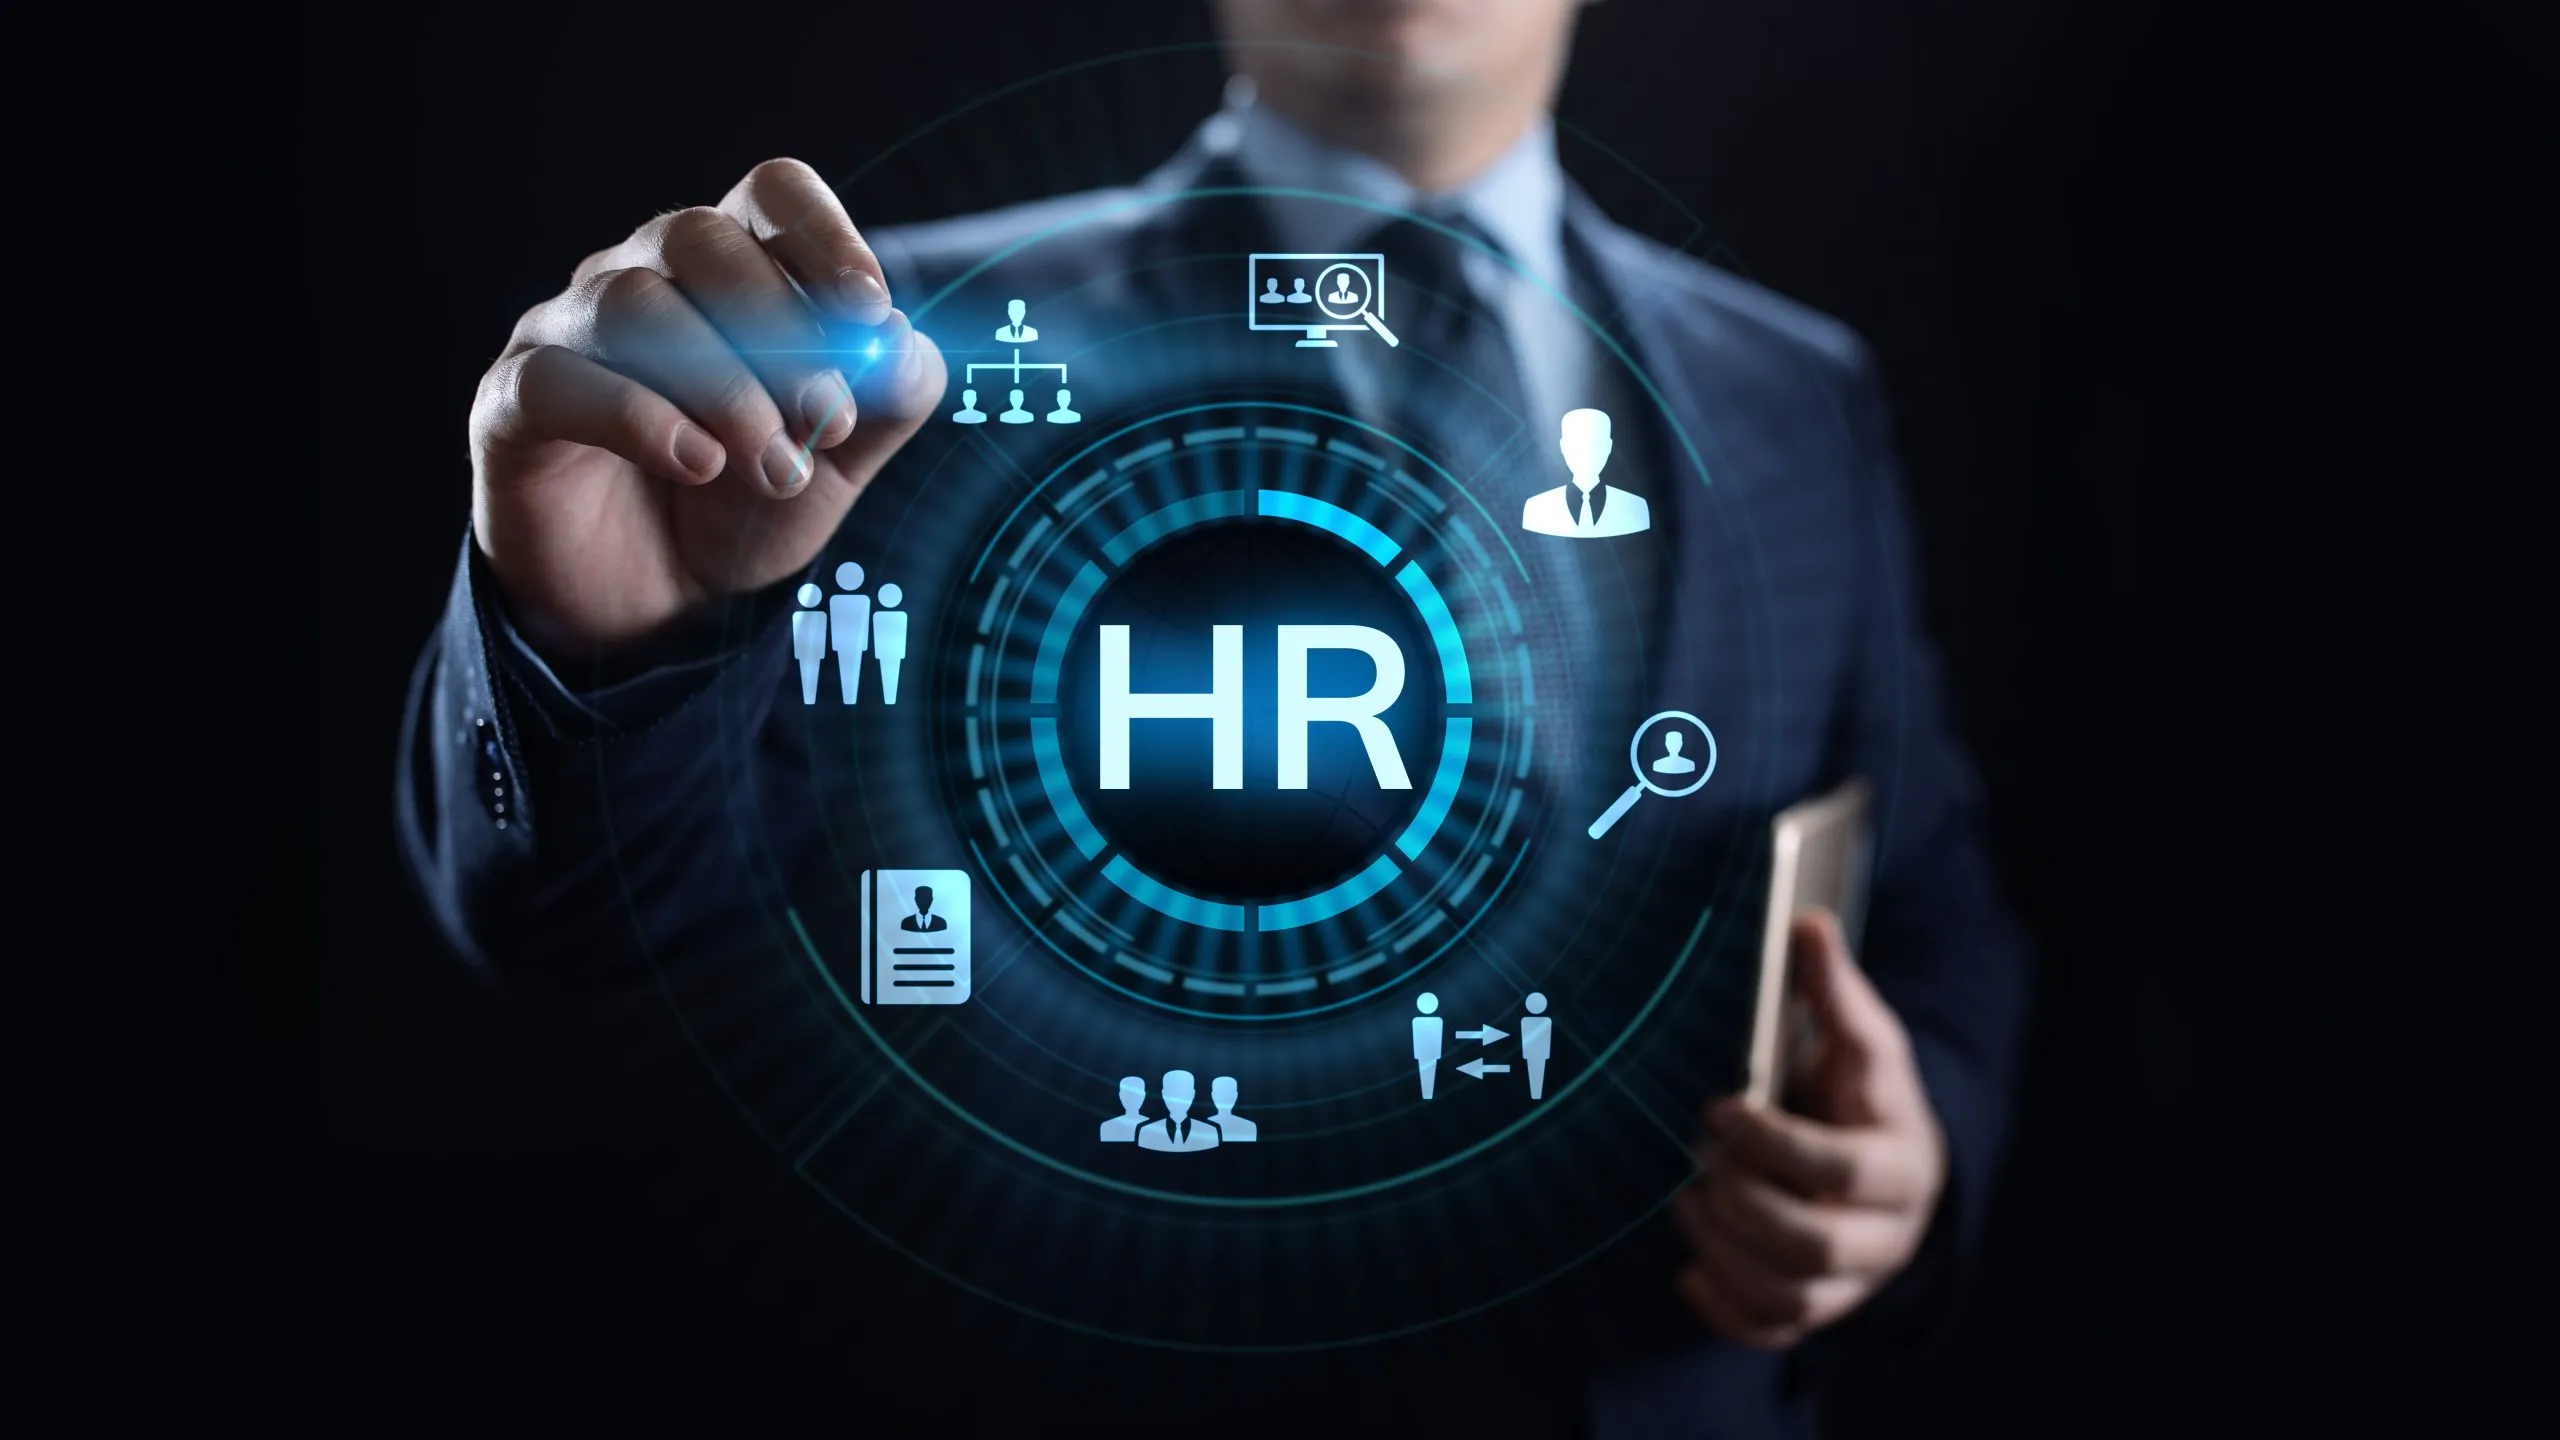

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
import plotly.express as px
warnings.filterwarnings('ignore')
df = pd.read_csv("Final_HR_Data(in).csv")
df.head()

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,State,Ethnicity,Education,...,PerformanceID,ReviewDate,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken,WorkLifeBalance,SelfRating,ManagerRating
0,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,Illinois,White,Doctorate,...,PR1295,10/30/2016,Neutral,Neutral,Slightly Satisfied,3,0,Slightly Balanced,Good,Good
1,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,Illinois,White,Doctorate,...,PR1908,10/30/2017,Satisfied,Satisfied,Very Satisfied,3,1,Slightly Unbalanced,Good,Fair
2,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,Illinois,White,Doctorate,...,PR2617,10/30/2018,Very Satisfied,Very Satisfied,Satisfied,3,0,Slightly Balanced,Excellent,Excellent
3,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,Illinois,White,Doctorate,...,PR3436,10/30/2019,Dissatisfied,Neutral,Slightly Satisfied,3,1,Neutral,Excellent,Very Good
4,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,Illinois,White,Doctorate,...,PR411,10/31/2014,Neutral,Satisfied,Slightly Satisfied,1,0,Neutral,Very Good,Good


In [51]:
df.describe()

,Age,Salary,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager,YearsAtCompany_Calculated,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken
count,6899.000000,6899.000000,6899.000000,6899.000000,6899.000000,6899.000000,6899.000000,6899.000000,6899.000000
mean,30.604146,110898.374112,5.578055,2.778953,4.143934,2.741412,9.276127,1.957530,0.989274
std,7.986542,98427.862382,3.410087,2.810170,3.203770,2.792284,3.137985,0.873447,0.951811
min,18.000000,20387.000000,0.000000,0.000000,0.000000,0.000000,2.300000,0.000000,0.000000
25%,25.000000,44646.000000,3.000000,0.000000,1.000000,0.000000,6.900000,1.000000,0.000000
50%,28.000000,74458.000000,6.000000,2.000000,4.000000,2.000000,9.900000,2.000000,1.000000
75%,36.000000,137219.500000,9.000000,5.000000,7.000000,5.000000,11.800000,3.000000,2.000000
max,51.000000,547204.000000,10.000000,10.000000,10.000000,10.000000,13.300000,3.000000,3.000000


In [52]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6899 entries, 0 to 6898
Data columns (total 32 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   EmployeeID                       6899 non-null   object 
 1   FirstName                        6899 non-null   object 
 2   LastName                         6899 non-null   object 
 3   Gender                           6899 non-null   object 
 4   Age                              6899 non-null   int64  
 5   BusinessTravel                   6899 non-null   object 
 6   Department                       6899 non-null   object 
 7   State                            6899 non-null   object 
 8   Ethnicity                        6899 non-null   object 
 9   Education                        6899 non-null   object 
 10  EducationField                   6899 non-null   object 
 11  JobRole                          6899 non-null   object 
 12  MaritalStatus       

In [53]:
df.isnull().sum()

EmployeeID                         0
FirstName                          0
LastName                           0
Gender                             0
Age                                0
BusinessTravel                     0
Department                         0
State                              0
Ethnicity                          0
Education                          0
EducationField                     0
JobRole                            0
MaritalStatus                      0
Salary                             0
OverTime                           0
YearsAtCompany                     0
YearsInMostRecentRole              0
YearsSinceLastPromotion            0
YearsWithCurrManager               0
StockOptions                       0
StillEmployed                      0
YearsAtCompany_Calculated          0
PerformanceID                      0
ReviewDate                         0
EnvironmentSatisfaction            0
JobSatisfaction                    0
RelationshipSatisfaction           0
T

In [54]:
df.duplicated().sum()

0

# What is the gender distribution of employees?

Remaining Gender Categories: ['Female' 'Male']


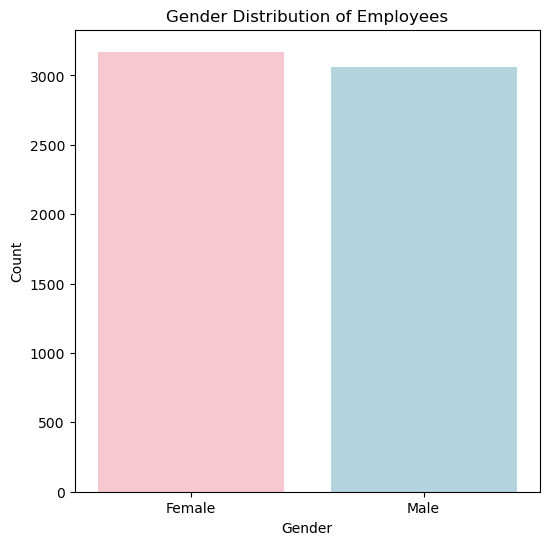

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
df = df[~df['Gender'].isin(['Non-Binary', 'Prefer Not To Say'])]
print("Remaining Gender Categories:", df['Gender'].unique())
# Plot gender distribution
plt.figure(figsize=(6,6))
sns.countplot(x=df['Gender'], palette=['pink', 'lightBlue'])
plt.title("Gender Distribution of Employees")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

# Does salary vary significantly across departments?

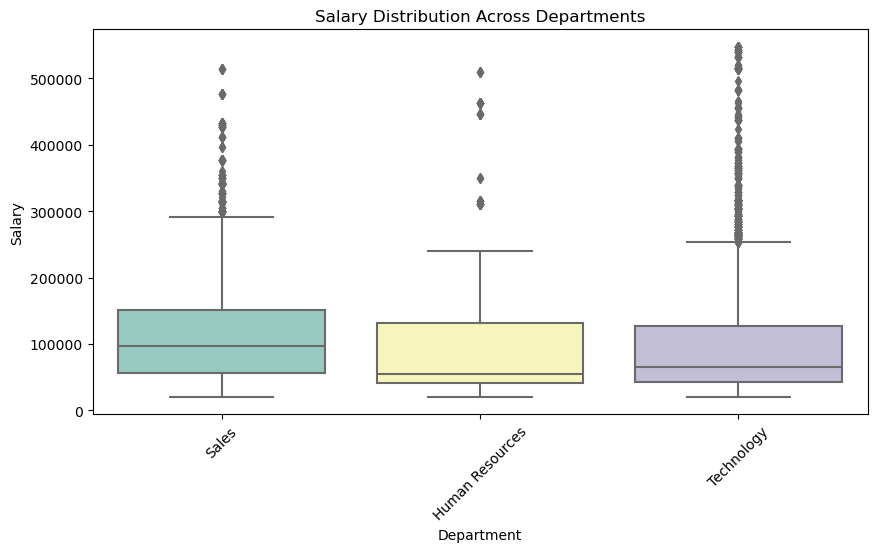

In [15]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Department', y='Salary', data=df, palette='Set3')
plt.title("Salary Distribution Across Departments")
plt.xticks(rotation=45)
plt.show()

# What is the relationship between salary and years of experience ?

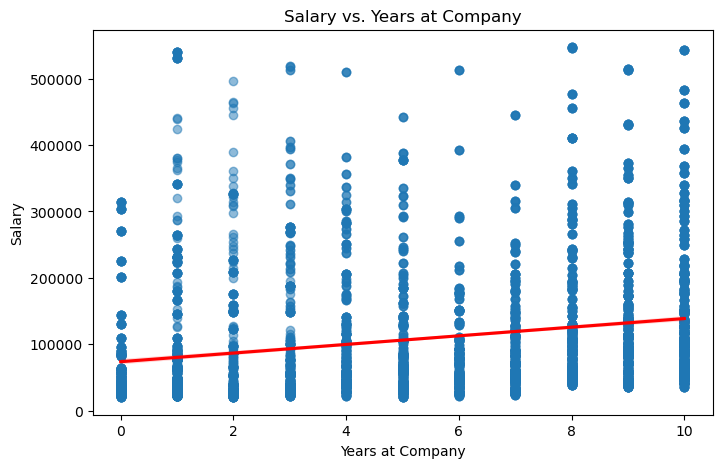

In [17]:
plt.figure(figsize=(8,5))
sns.regplot(x='YearsAtCompany', y='Salary', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title("Salary vs. Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Salary")
plt.show()
#Each dot represents an employee, plotting their Years at Company against their Salary.

#The red regression line helps identify trends between these two variables.

# What is the distribution of employee ethnicity across different departments ?

<Axes: xlabel='Department'>

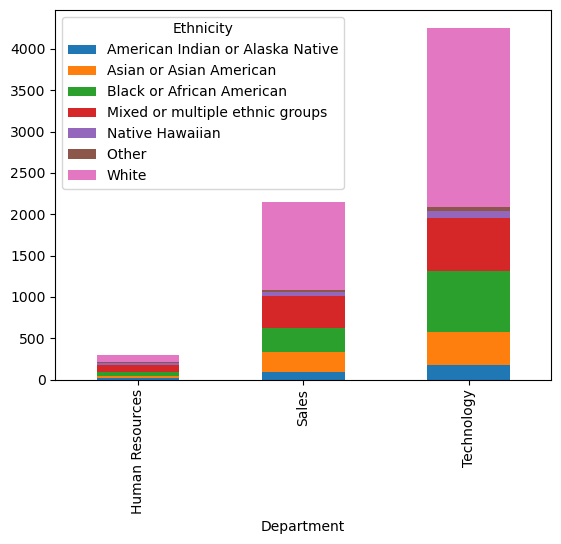

In [20]:
# Ethnicity by department
pd.crosstab(df['Department'], df['Ethnicity']).plot(kind='bar', stacked=True)


# How do job satisfaction levels change across different departments ?

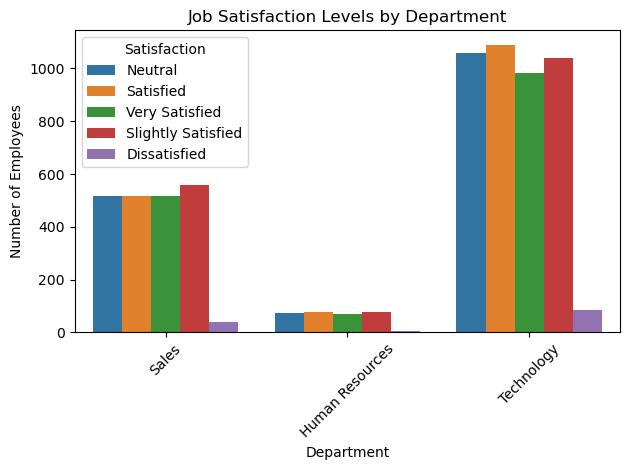

In [48]:
sns.countplot(data=df, x='Department', hue='JobSatisfaction')
plt.xticks(rotation=45)
plt.title('Job Satisfaction Levels by Department')
plt.ylabel('Number of Employees')
plt.xlabel('Department')
plt.legend(title='Satisfaction')
plt.tight_layout()
plt.show()


# What is the average number of training opportunities taken in each department ?

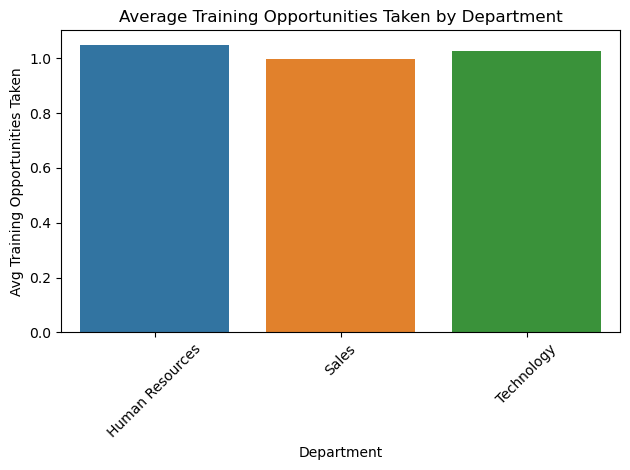

In [13]:
# Group by Department and calculate the mean
grouped = df.groupby('Department')['TrainingOpportunitiesTaken'].mean().reset_index()
sns.barplot(data=grouped, x='Department', y='TrainingOpportunitiesTaken')
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.title('Average Training Opportunities Taken by Department')
plt.ylabel('Avg Training Opportunities Taken')
plt.xlabel('Department')
plt.tight_layout()
plt.show()


# What is the gender distribution across different departments ?

Remaining Gender Categories: ['Female' 'Male']


<Axes: xlabel='Gender', ylabel='count'>

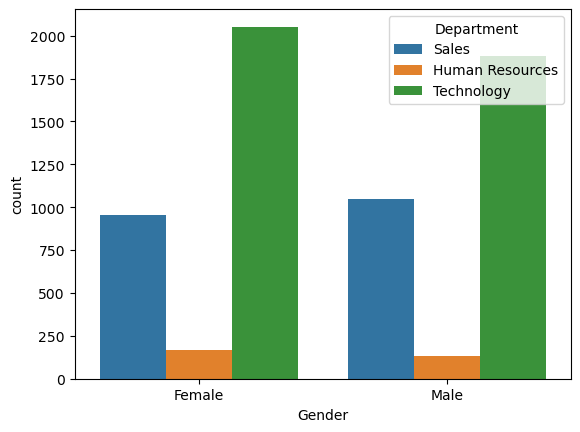

In [41]:
f = df[~df['Gender'].isin(['Non-Binary', 'Prefer Not To Say'])]
print("Remaining Gender Categories:", df['Gender'].unique())
sns.countplot(data=df, x='Gender', hue='Department')

# What is the age distribution of employees ?

<Axes: xlabel='Age', ylabel='Count'>

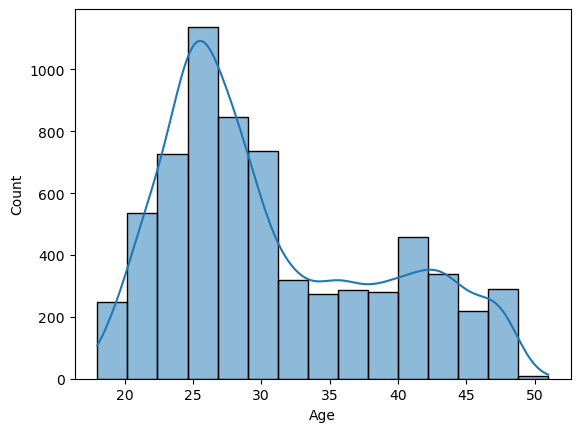

In [55]:
sns.histplot(data=df, x='Age', bins=15, kde=True)

# How does salary vary with the number of years an employee has been at the company ?

Text(0.5, 1.0, 'Salary Distribution by Years at Company')

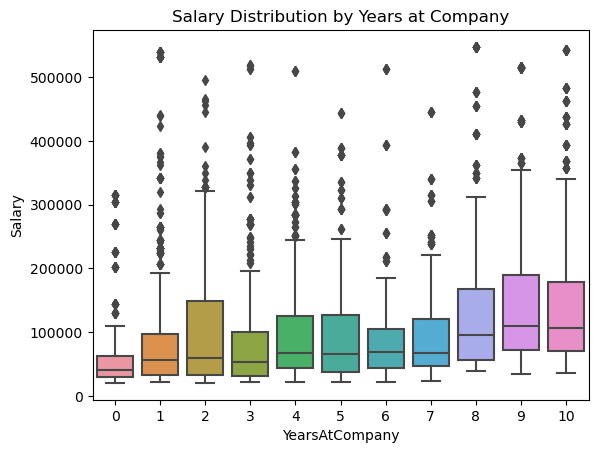

In [64]:
sns.boxplot(data=df, x='YearsAtCompany', y='Salary')
plt.title('Salary Distribution by Years at Company')


# How does the frequency of business travel vary within the company ? 

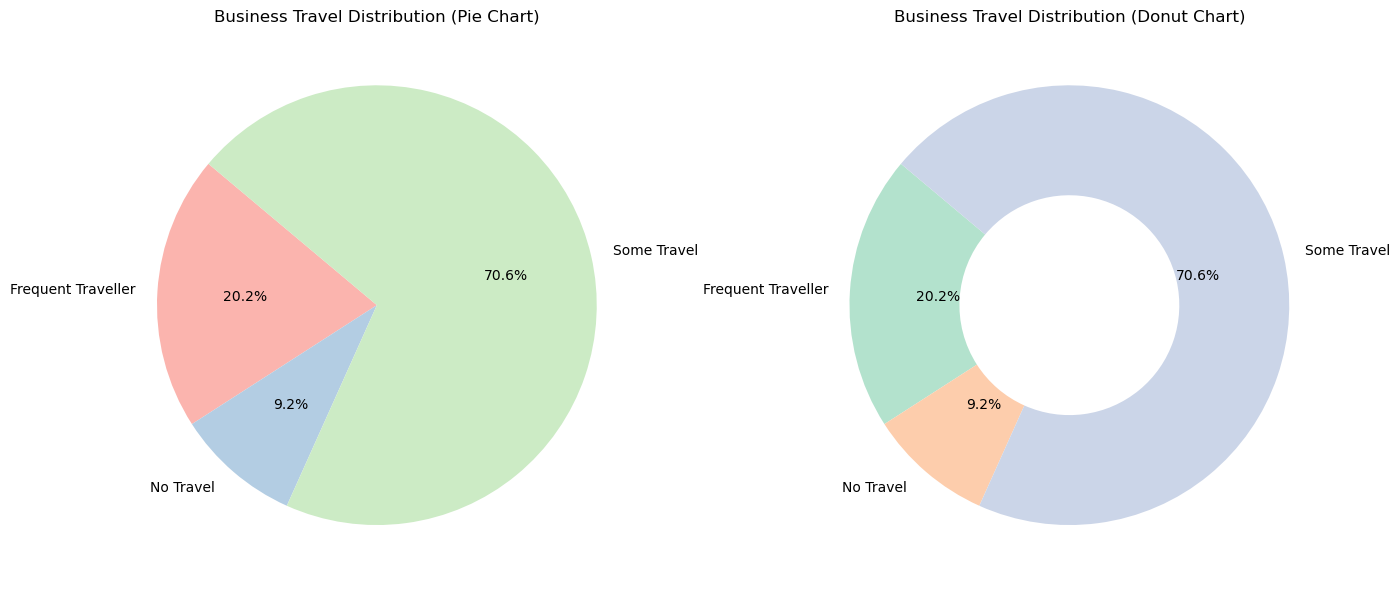

In [3]:
balance_counts = df['BusinessTravel'].value_counts().sort_index()
labels = balance_counts.index
sizes = balance_counts.values
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.Pastel1.colors)
plt.title('Business Travel Distribution (Pie Chart)')
plt.subplot(1, 2, 2)
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Pastel2.colors,
    wedgeprops=dict(width=0.5))
plt.title('Business Travel Distribution (Donut Chart)')

plt.tight_layout()
plt.show()

# How do different satisfaction levels correlate with performance ratings?"

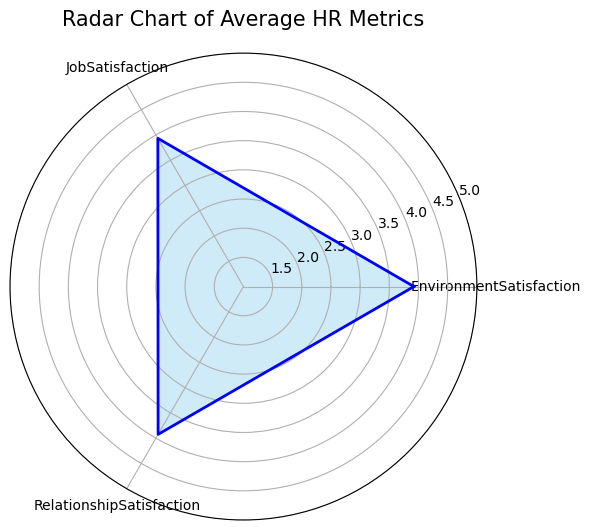

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
columns = ['EnvironmentSatisfaction', 'JobSatisfaction', 'RelationshipSatisfaction']
satisfaction_mapping = { 'Dissatisfied': 1,'Slightly Dissatisfied': 2,'Neutral': 3,'Satisfied': 4,'Very Satisfied': 5}
# Map satisfaction scores
for col in columns:
    if df[col].dtype == 'object':
        df[col] = df[col].map(satisfaction_mapping)
# Calculate mean values
values = df.mean().values
labels = df.columns.tolist()
num_vars = len(labels)
# Calculate angles for radar chart
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
values = np.concatenate((values, [values[0]]))  # Close the circle
angles += angles[:1]
# Plot
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, values, color='blue', linewidth=2)
ax.fill(angles, values, color='skyblue', alpha=0.4)
# Set axis labels and title
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(1, 5)  # Set radial range to match satisfaction scale
ax.set_title("Radar Chart of Average HR Metrics", size=15, pad=20)
plt.tight_layout()
plt.show()


# What job role is most likely to work overtime ?


Overtime Percentage by Job Role:
 OverTime                     No   Yes
JobRole                              
Analytics Manager          65.7  34.3
Data Scientist             68.5  31.5
Engineering Manager        76.2  23.8
HR Business Partner        64.0  36.0
HR Executive               82.4  17.6
HR Manager                 70.6  29.4
Machine Learning Engineer  72.0  28.0
Manager                    68.3  31.7
Recruiter                  59.9  40.1
Sales Executive            66.0  34.0
Sales Representative       64.8  35.2
Senior Software Engineer   76.6  23.4
Software Engineer          58.9  41.1


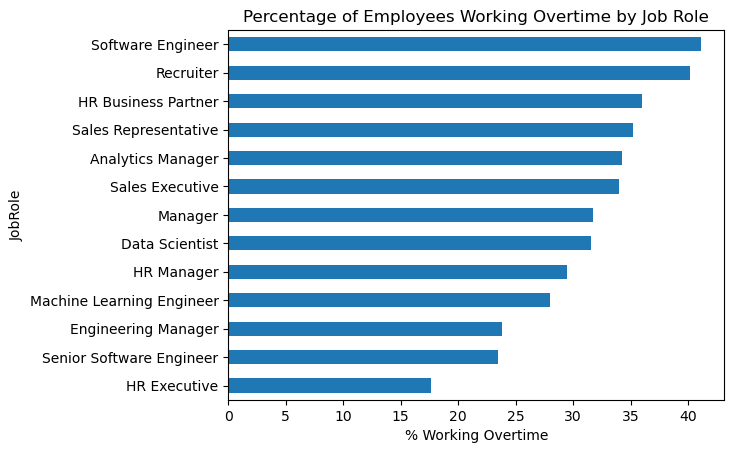

In [79]:
# Calculate overtime percentage
overtime_percent = df.groupby('JobRole')['OverTime'].value_counts(normalize=True).unstack() * 100
print("\nOvertime Percentage by Job Role:\n", overtime_percent.round(1))

# Simple horizontal bar chart
overtime_percent['Yes'].sort_values().plot(kind='barh')
plt.title('Percentage of Employees Working Overtime by Job Role')
plt.xlabel('% Working Overtime')
plt.show()

# How does salary affected by education level ?


Average Salary by Education:
                Education    Salary
0      Bachelor's Degree  115837.0
1              Doctorate  159004.0
2            High School  103431.0
3  Less than High School   91528.0
4        Master's Degree  112656.0


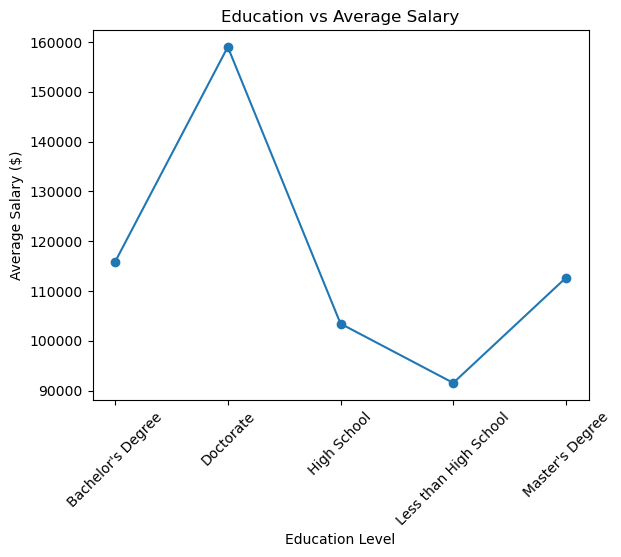

In [80]:
# Group by education level
education_salary = df.groupby('Education')['Salary'].mean().reset_index()
print("\nAverage Salary by Education:\n", education_salary.round(0))
# Simple line plot
plt.plot(education_salary['Education'], education_salary['Salary'], marker='o')
plt.title('Education vs Average Salary')
plt.xlabel('Education Level')
plt.ylabel('Average Salary ($)')
plt.xticks(rotation=45)
plt.show()

# How does employee retention change over time ?

Data Types:
StillEmployed     int64
YearsAtCompany    int64
dtype: object

Sample Data:
   StillEmployed  YearsAtCompany
0              1              10
1              1              10
2              1              10
3              1              10
4              1              10

Retention Rates:
    YearsAtCompany  StillEmployed
0                0       0.190896
1                1       0.168360
2                2       0.291176
3                3       0.496703
4                4       0.684435
5                5       0.617591
6                6       0.768085
7                7       0.861538
8                8       0.919463
9                9       0.940618
10              10       0.990338


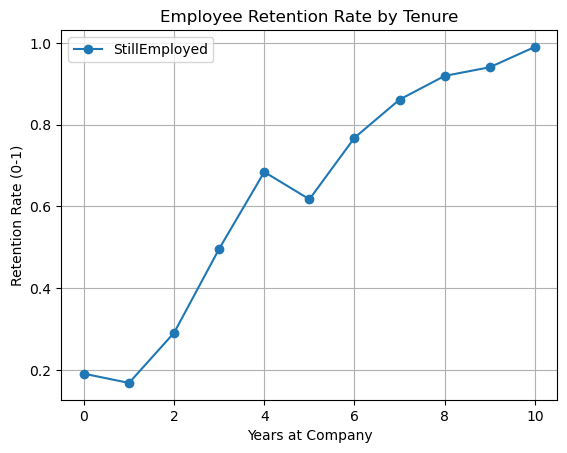

In [81]:
df = pd.read_csv('Final_HR_Data(in).csv')

# Clean and convert columns
df['StillEmployed'] = df['StillEmployed'].map({'Yes': 1, 'No': 0})
df['YearsAtCompany'] = pd.to_numeric(df['YearsAtCompany'], errors='coerce')

# Remove rows with invalid data
df = df.dropna(subset=['StillEmployed', 'YearsAtCompany'])

# Verify conversions
print("Data Types:")
print(df[['StillEmployed', 'YearsAtCompany']].dtypes)
print("\nSample Data:")
print(df[['StillEmployed', 'YearsAtCompany']].head())

# Calculate retention rates
retention = df.groupby('YearsAtCompany')['StillEmployed'].mean().reset_index()
print("\nRetention Rates:")
print(retention)

# Simple plot
retention.plot(x='YearsAtCompany', y='StillEmployed', kind='line', marker='o')
plt.title('Employee Retention Rate by Tenure')
plt.xlabel('Years at Company')
plt.ylabel('Retention Rate (0-1)')
plt.grid(True)
plt.show()